In [295]:
import jax.numpy as jnp
import jax.random as random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import corner
import pandas as pd


# Model Functions

In [296]:
priormin = 0
priormax = 2

In [297]:
def gaussian_normal(data, err):
    """
    Single Gaussian model with uniform priors.
    """
    mu = numpyro.sample('mu', dist.Normal(priormin, priormax))
    sigma = numpyro.sample('sigma', dist.HalfNormal(priormax))
    with numpyro.plate('data', len(data)):
        numpyro.sample('obs', dist.Normal(mu, jnp.sqrt(sigma**2 + err**2)), obs=data)

def gaussian_uniform(data, err):
    """
    Single Gaussian model with normal priors.
    """
    mu = numpyro.sample('mu', dist.Uniform(priormin, priormax))
    sigma = numpyro.sample('sigma', dist.Uniform(priormin, priormax))
    with numpyro.plate('data', len(data)):
        numpyro.sample('obs', dist.Normal(mu, jnp.sqrt(sigma**2 + err**2)), obs=data)


def double_gaussian_uniform(data, err):
    mu1 = numpyro.sample('mu1', dist.Uniform(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Uniform(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.Uniform(priormin,priormax))
    sigma2 = numpyro.sample('sigma2', dist.Uniform(priormin, priormax))
    weight = numpyro.sample('weight', dist.Uniform(0, 1)) # only goes up to 0.5 so that there isn't a reversal of the two gaussians

    with numpyro.plate('data', len(data)):
        scale1 = jnp.sqrt(sigma1**2 + err**2)
        scale2 = jnp.sqrt(sigma2**2 + err**2)

        logp1 = dist.Normal(mu1, scale1).log_prob(data)
        logp2 = dist.Normal(mu2, scale2).log_prob(data)

        log_mix = jnp.logaddexp(jnp.log(weight) + logp1,
                                jnp.log1p(-weight) + logp2)
        numpyro.factor("obs", jnp.sum(log_mix))

def double_gaussian_normal(data, err):
    mu1 = numpyro.sample('mu1', dist.Normal(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Normal(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.HalfNormal(priormax))
    sigma2 = numpyro.sample('sigma2', dist.HalfNormal(priormax))
    weight = numpyro.sample('weight', dist.Uniform(0, 1))

    with numpyro.plate('data', len(data)):
        scale1 = jnp.sqrt(sigma1**2 + err**2)
        scale2 = jnp.sqrt(sigma2**2 + err**2)

        logp1 = dist.Normal(mu1, scale1).log_prob(data)
        logp2 = dist.Normal(mu2, scale2).log_prob(data)

        log_mix = jnp.logaddexp(jnp.log(weight) + logp1,
                                jnp.log1p(-weight) + logp2)
        numpyro.factor("obs", jnp.sum(log_mix))

def double_gaussian_normal_beta(data, err):
    mu1 = numpyro.sample('mu1', dist.Normal(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Normal(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.HalfNormal(priormax))
    sigma2 = numpyro.sample('sigma2', dist.HalfNormal(priormax))
    weight = numpyro.sample('weight', dist.Beta(2, 2))

    with numpyro.plate('data', len(data)):
        scale1 = jnp.sqrt(sigma1**2 + err**2)
        scale2 = jnp.sqrt(sigma2**2 + err**2)

        logp1 = dist.Normal(mu1, scale1).log_prob(data)
        logp2 = dist.Normal(mu2, scale2).log_prob(data)

        log_mix = jnp.logaddexp(jnp.log(weight) + logp1,
                                jnp.log1p(-weight) + logp2)
        numpyro.factor("obs", jnp.sum(log_mix))

def double_gaussian_uniform_beta(data, err):
    mu1 = numpyro.sample('mu1', dist.Uniform(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Uniform(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.Uniform(priormin, priormax))
    sigma2 = numpyro.sample('sigma2', dist.Uniform(priormin, priormax))
    weight = numpyro.sample('weight', dist.Beta(2, 2))

    with numpyro.plate('data', len(data)):
        scale1 = jnp.sqrt(sigma1**2 + err**2)
        scale2 = jnp.sqrt(sigma2**2 + err**2)

        logp1 = dist.Normal(mu1, scale1).log_prob(data)
        logp2 = dist.Normal(mu2, scale2).log_prob(data)

        log_mix = jnp.logaddexp(jnp.log(weight) + logp1,
                                jnp.log1p(-weight) + logp2)
        numpyro.factor("obs", jnp.sum(log_mix))

In [298]:
### Prior Functions - not used for inference, just for plotting
def prior_gaussian_normal(): 
    params = dict()
    mu = numpyro.sample('mu', dist.Normal(priormin, priormax))
    sigma = numpyro.sample('sigma', dist.HalfNormal(priormax))
    return params

def prior_gaussian_uniform():
    params = dict()
    mu = numpyro.sample('mu', dist.Uniform(priormin, priormax))
    sigma = numpyro.sample('sigma', dist.Uniform(priormin, priormax))
    return params

def prior_double_gaussian_uniform():
    params = dict()
    mu1 = numpyro.sample('mu1', dist.Uniform(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Uniform(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.Uniform(priormin,priormax))
    sigma2 = numpyro.sample('sigma2', dist.Uniform(priormin,priormax))
    weight = numpyro.sample('weight', dist.Uniform(0, 1))
    return params 

def prior_double_gaussian_normal():
    params = dict()
    mu1 = numpyro.sample('mu1', dist.Normal(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Normal(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.HalfNormal(priormax))
    sigma2 = numpyro.sample('sigma2', dist.HalfNormal(priormax))
    weight = numpyro.sample('weight', dist.Uniform(0, 1))
    return params

def prior_double_gaussian_normal_beta():
    params = dict()
    mu1 = numpyro.sample('mu1', dist.Normal(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Normal(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.HalfNormal(priormax))
    sigma2 = numpyro.sample('sigma2', dist.HalfNormal(priormax))
    weight = numpyro.sample('weight', dist.Beta(2, 2))
    return params


In [299]:
def run_inference(model, data, err, rng_key, num_warmup=5000, num_samples=5000):
    kernel = NUTS(model)
    mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
    mcmc.run(rng_key, data=data, err=err)
    return mcmc

# def log_marginal_likelihood(mcmc, model, data, err):
#     loglik = log_likelihood(model, mcmc.get_samples(), data=data, err=err)['obs']
#     return jnp.sum(jnp.log(jnp.mean(jnp.exp(loglik), axis=0)))

In [300]:
def plot_posterior_distributions(mcmc, model_type, data, label):
    samples = mcmc.get_samples()
    x = np.linspace(min(data) - 0.2, max(data) + 0.2, 1000)

    plt.figure(figsize=(8, 5))

    if model_type == "single":
        mu = samples['mu']
        sigma = samples['sigma']
        for i in np.random.choice(len(mu), 100, replace=False):
            y = scipy.stats.norm.pdf(x, loc=mu[i], scale=np.sqrt(sigma[i]**2))
            plt.plot(x, y, alpha=0.1, color='C0')
        plt.title(f"Posterior Predictive - Single Gaussian ({label})")

    elif model_type == "double":
        mu1 = samples['mu1']
        mu2 = samples['mu2']
        sigma1 = samples['sigma1']
        sigma2 = samples['sigma2']
        weight = samples['weight']

        for i in np.random.choice(len(mu1), 100, replace=False):
            w = weight[i]
            y = (
                w * scipy.stats.norm.pdf(x, loc=mu1[i], scale=np.sqrt(sigma1[i]**2)) +
                (1 - w) * scipy.stats.norm.pdf(x, loc=mu2[i], scale=np.sqrt(sigma2[i]**2))
            )
            plt.plot(x, y, alpha=0.1, color='C1')
        plt.title(f"Posterior Predictive - Two-Gaussian ({label})")

    plt.xlabel("x")
    plt.ylabel("Density")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_multiple_posterior_distributions(mcmc_list, model_types, data, labels):
    """
    Plots multiple posterior predictive distributions on the same plot.

    Parameters:
    - mcmc_list: List of MCMC objects containing posterior samples.
    - model_types: List of model types corresponding to each MCMC object ("single" or "double").
    - data: The observed data used to define the x-axis range.
    - labels: List of labels for each posterior predictive distribution.
    """
    x = np.linspace(min(data) - 0.2, max(data) + 0.2, 1000)

    plt.figure(figsize=(10, 6))

    for mcmc, model_type, label in zip(mcmc_list, model_types, labels):
        samples = mcmc.get_samples()

        if model_type == "single":
            mu = samples['mu']
            sigma = samples['sigma']
            density = np.zeros_like(x)
            for i in np.random.choice(len(mu), 100, replace=False):
                density += scipy.stats.norm.pdf(x, loc=mu[i], scale=np.sqrt(sigma[i]**2))
            density /= 100
            plt.plot(x, density, label=f"{label} (Single Gaussian)")

        elif model_type == "double":
            mu1 = samples['mu1']
            mu2 = samples['mu2']
            sigma1 = samples['sigma1']
            sigma2 = samples['sigma2']
            weight = samples['weight']
            density = np.zeros_like(x)
            for i in np.random.choice(len(mu1), 100, replace=False):
                w = weight[i]
                density += (
                    w * scipy.stats.norm.pdf(x, loc=mu1[i], scale=np.sqrt(sigma1[i]**2)) +
                    (1 - w) * scipy.stats.norm.pdf(x, loc=mu2[i], scale=np.sqrt(sigma2[i]**2))
                )
            density /= 100
            plt.plot(x, density, label=f"{label} (Two-Gaussian)")

    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title("Multiple Posterior Predictive Distributions")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Load in Data

In [301]:
data = pd.read_csv("/Users/aryannaschiebelbein/Library/CloudStorage/OneDrive-UniversityofToronto/NS_data.csv")

DNS = data[data['type'] == 'NS-NS']
Gaia = data[data['type'] == 'Gaia']
NSWD = data[data['type'] == 'NS-WD']

In [302]:
gaia_data = np.array(Gaia['m1'])  
gaia_data_err = np.array(Gaia[['m1_uerr', 'm1_lerr']].max(axis=1).dropna())  

DNS_data = np.array(DNS['m1'])  
DNS_data_err = np.array(DNS[['m1_uerr', 'm1_lerr']].max(axis=1))  #.dropna()
#print(DNS_data, DNS_data_err)


def plot_cdf(m, uerr, lerr):
    
    # m = pd.to_numeric(m, errors='coerce')
    # uerr = pd.to_numeric(uerr, errors='coerce')
    # lerr = pd.to_numeric(lerr, errors='coerce')

    sorted_idx = np.argsort(m)
    masses = m[sorted_idx] #m.iloc[sorted_idx].dropna()
    uerrors = uerr[sorted_idx]#]uerr.iloc[sorted_idx].dropna()
    lerrors = lerr[sorted_idx]#lerr.iloc[sorted_idx].dropna()

    masses = masses[~np.isnan(masses)]
    uerrors = uerrors[~np.isnan(uerrors)]
    lerrors = lerrors[~np.isnan(lerrors)]

    print(masses, uerrors)
    bins = list(masses)
    bins.append(max(masses))
    bins.insert(0,0)
    
    return(masses, uerrors, lerrors, bins)

# Gaia Mass Distribution Fit

sample: 100%|██████████| 2000/2000 [00:01<00:00, 1717.49it/s, 7 steps of size 4.84e-01. acc. prob=0.90]


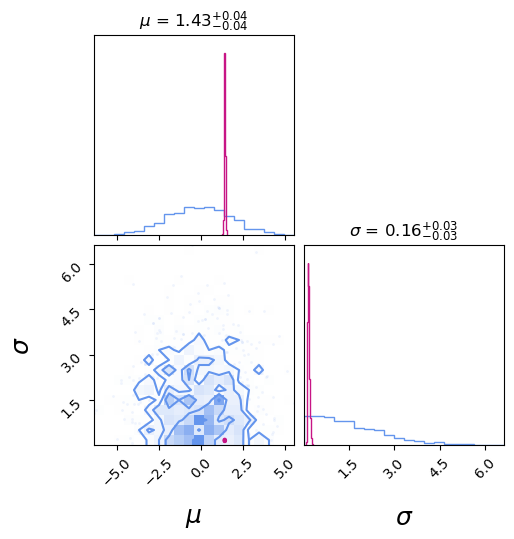

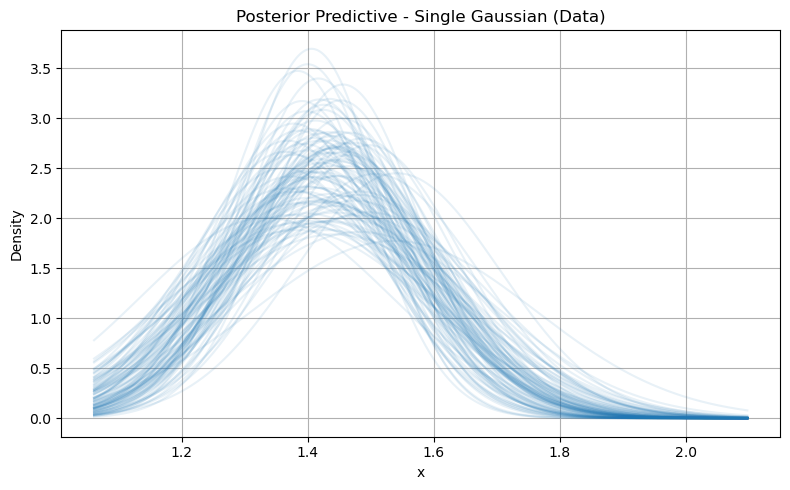

Single Gaussian (Normal Prior):
logl gaussian_normal:  1.4014469





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1913.32it/s, 3 steps of size 8.46e-01. acc. prob=0.91]


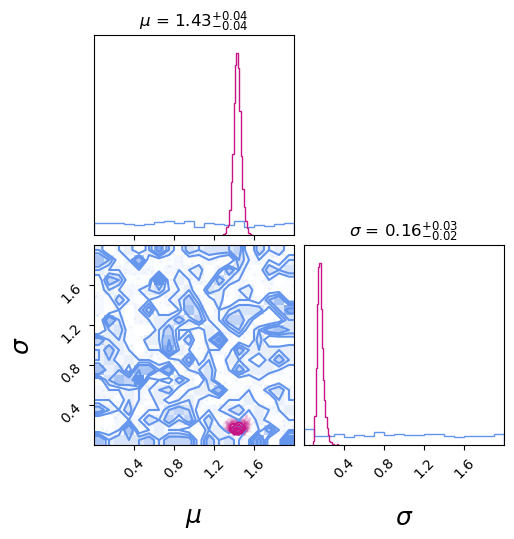

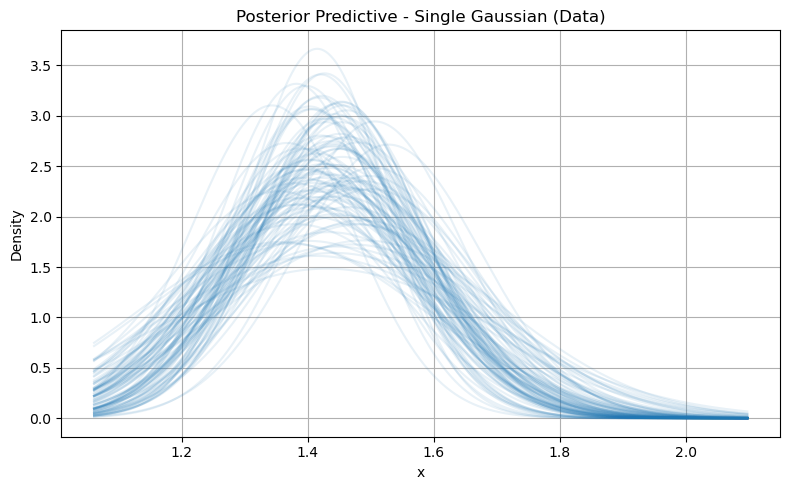

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  1.4098123





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1103.51it/s, 7 steps of size 3.78e-01. acc. prob=0.92] 


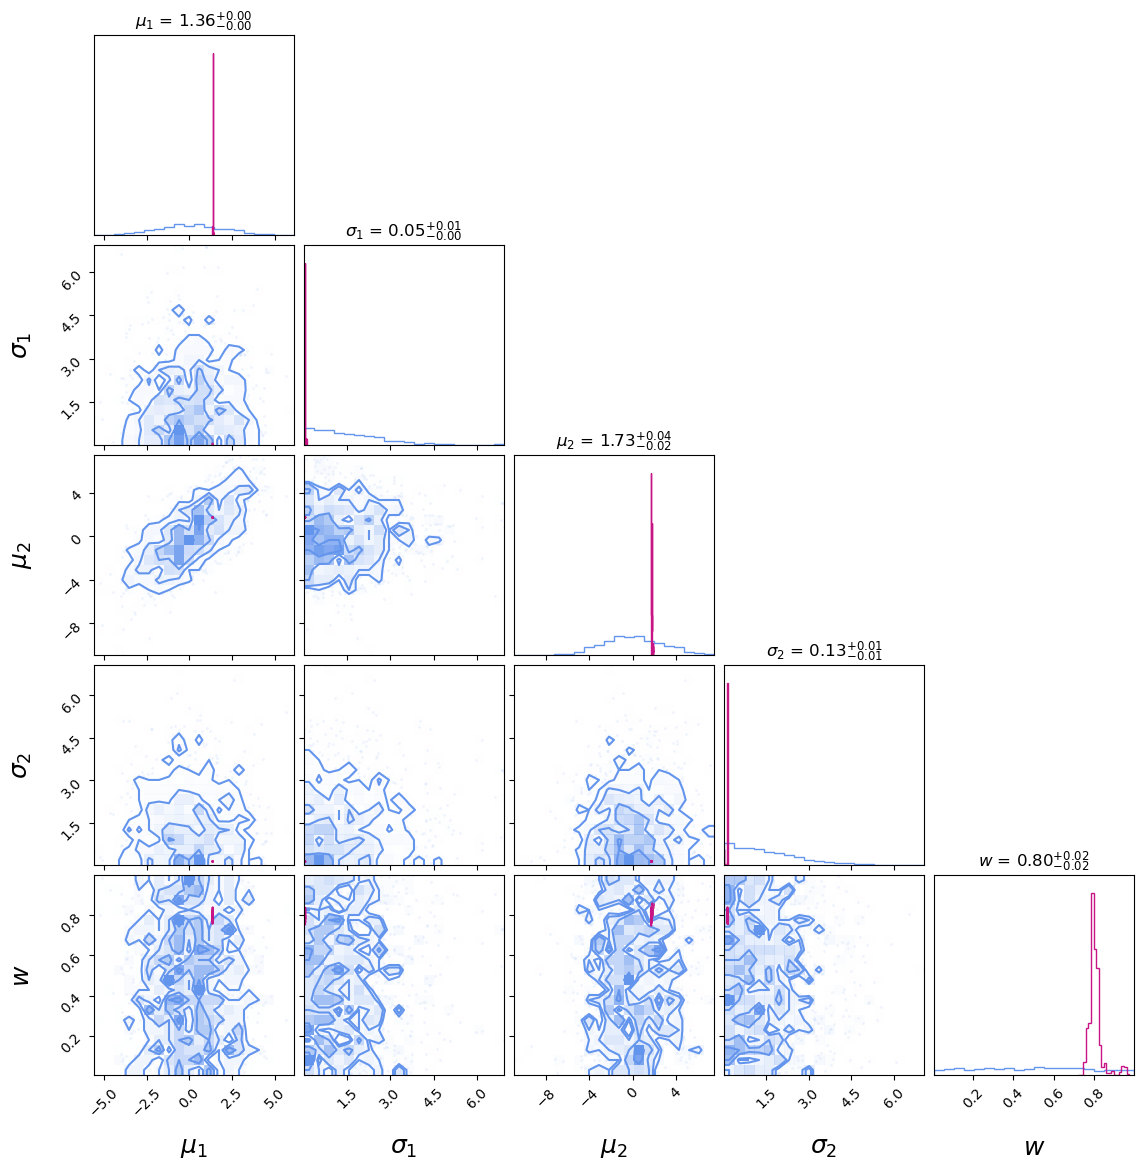

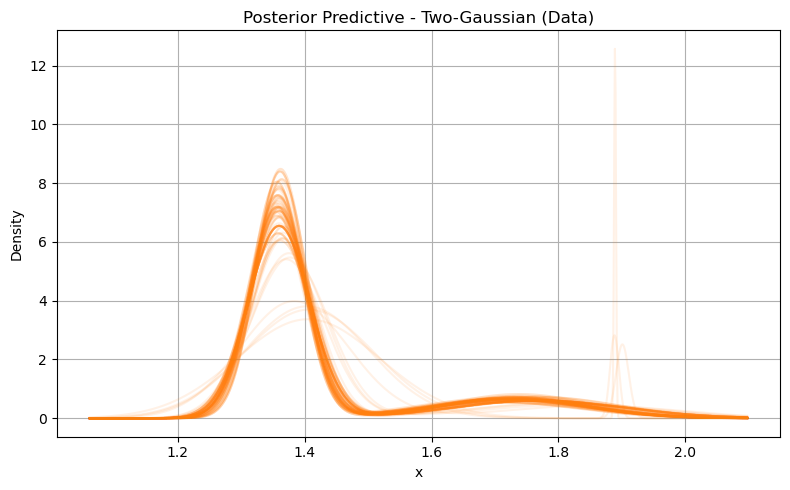

Double Gaussian (Normal Prior):
logl double_normal:  17.28116





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1509.63it/s, 7 steps of size 6.60e-01. acc. prob=0.90]


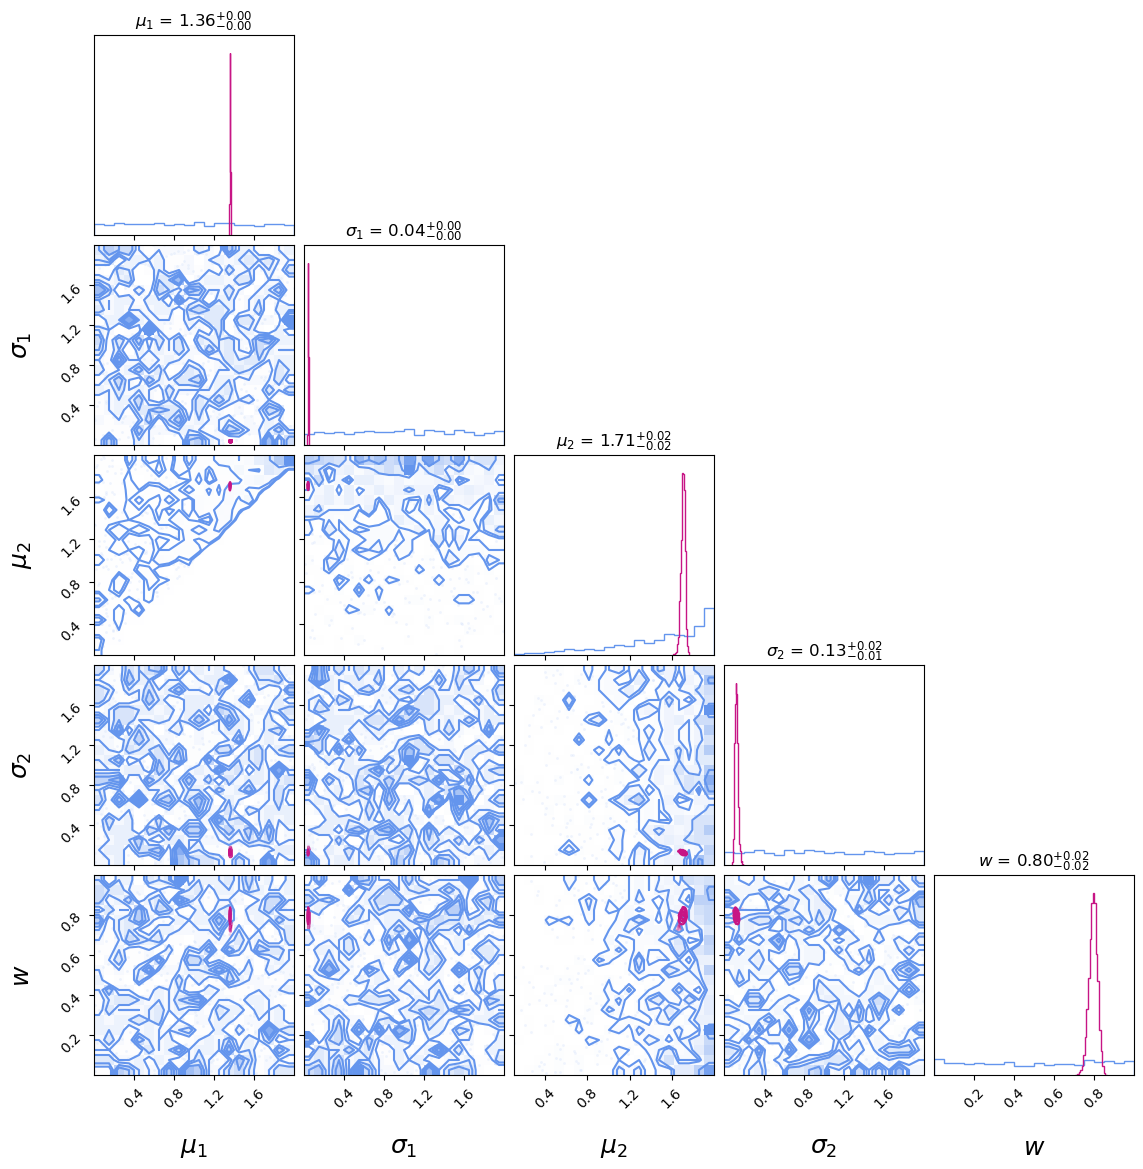

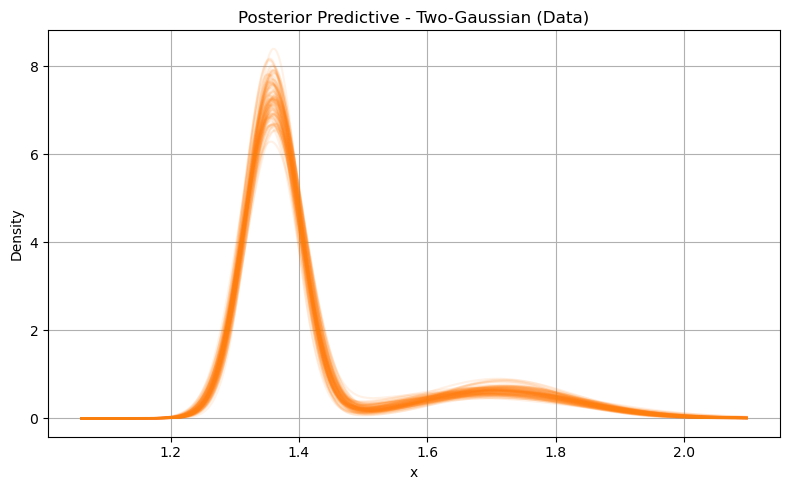

Double Gaussian (Uniform Prior):
logl double_uniform:  17.285875






sample: 100%|██████████| 2000/2000 [00:01<00:00, 1197.43it/s, 7 steps of size 3.94e-01. acc. prob=0.92]


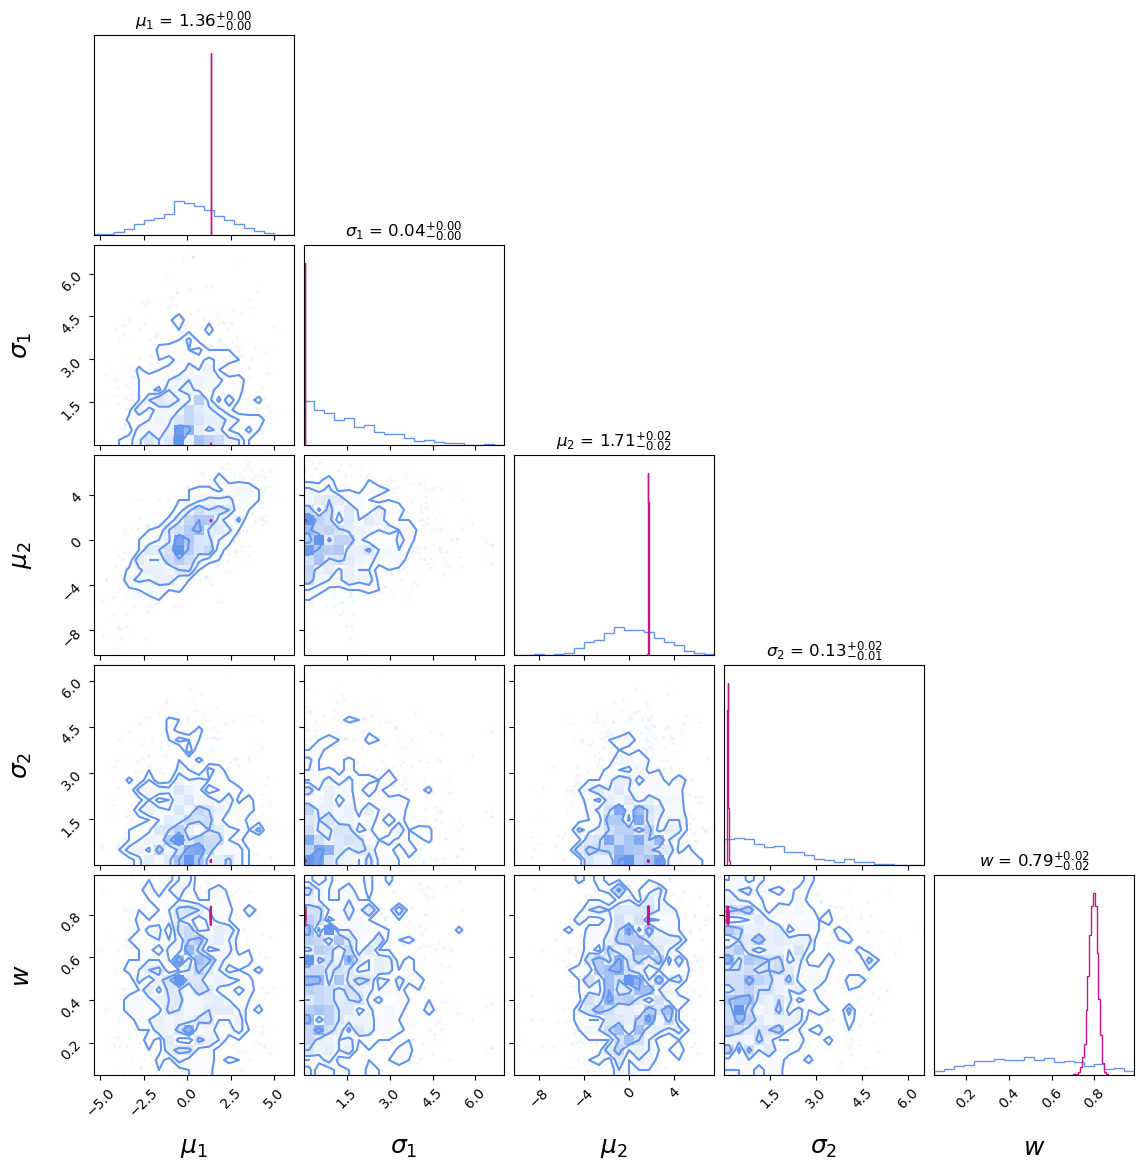

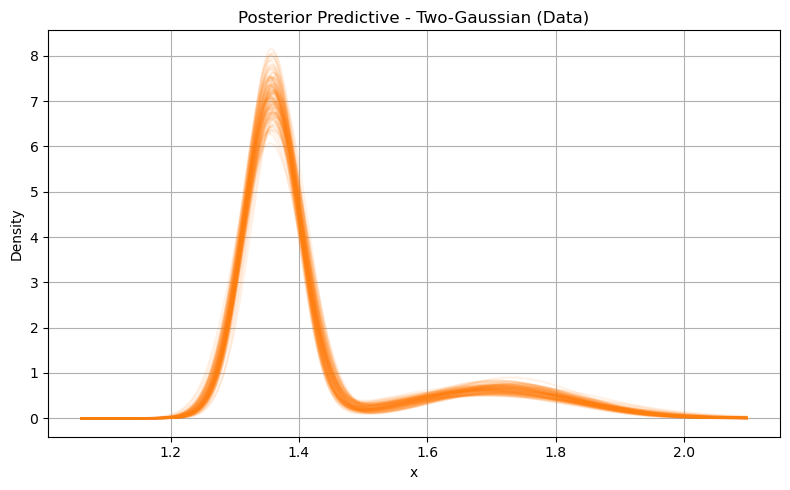

Double Gaussian (Beta Prior):
logl double_beta:  17.286522





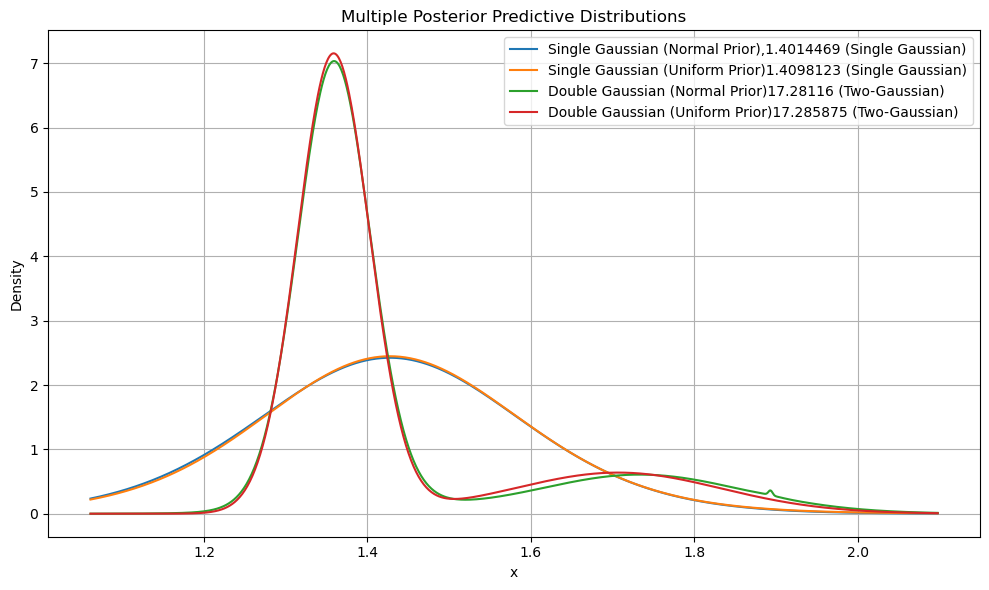

In [343]:
data = np.array(Gaia['m1'])  
data_err = np.array(Gaia[['m1_uerr', 'm1_lerr']].max(axis=1).dropna())  

rng = random.PRNGKey(0)

# Fit single Gaussian - normal prior
mcmc_gaussian_normal = run_inference(gaussian_normal, data, data_err, rng)
samples_gaussian_normal= az.from_numpyro(mcmc_gaussian_normal)
logZ_gaussian_normal = log_marginal_likelihood(mcmc_gaussian_normal, gaussian_normal, data, data_err)

prior_sampler = MCMC(NUTS(prior_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
corner.corner(
    samples_gaussian_normal,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_normal, "single", "Posterior: Single Gaussian - Normal Prior")
plot_posterior_distributions(mcmc_gaussian_normal, "single", data, label="Data")

print("Single Gaussian (Normal Prior):")
logl_gaussian_normal = log_likelihood(gaussian_normal, mcmc_gaussian_normal.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_normal: ", np.max(logl_gaussian_normal))
print()
print()
print()

# Fit single Gaussian - uniform prior
mcmc_gaussian_uniform = run_inference(gaussian_uniform, data, data_err, rng)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)
logZ_gaussian_uniform = log_marginal_likelihood(mcmc_gaussian_uniform, gaussian_uniform, data, data_err)

prior_sampler = MCMC(NUTS(prior_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_uniform, "single", "Posterior: Single Gaussian - Uniform Prior")
plot_posterior_distributions(mcmc_gaussian_uniform, "single", data, label="Data")


print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()


# Fit two-component Gaussian - normal prior
rng, rng2 = random.split(rng)
mcmc_double_normal = run_inference(double_gaussian_normal, data, data_err, rng2)
samples_double_normal = az.from_numpyro(mcmc_double_normal)
logZ_double_normal = log_marginal_likelihood(mcmc_double_normal, double_gaussian_normal, data, data_err)

prior_sampler = MCMC(NUTS(prior_double_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_normal,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()
#corner_plot(mcmc_double_normal, "double", "Posterior: Two-Gaussian Mixture - Normal Prior")
plot_posterior_distributions(mcmc_double_normal, "double", data, label="Data")

print("Double Gaussian (Normal Prior):")
logl_double_normal = log_likelihood(double_gaussian_normal, mcmc_double_normal.get_samples(), data=data, err=data_err)['obs']
print("logl double_normal: ", np.max(logl_double_normal))
print()
print()
print()

# Fit two-component Gaussian - Uniform prior
rng, rng2 = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, data, data_err, rng2)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)
logZ_double_uniform = log_marginal_likelihood(mcmc_double_uniform, double_gaussian_uniform, data, data_err)

prior_sampler = MCMC(NUTS(prior_double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

gaia_corner_samples = samples_double_uniform

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

#corner_plot(mcmc_double_uniform, "double", "Posterior: Two-Gaussian Mixture - Uniform Prior")
plot_posterior_distributions(mcmc_double_uniform, "double", data, label="Data")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()
print()

# Fit two-component Gaussian - Beta prior
rng, rng2 = random.split(rng)
mcmc_double_beta = run_inference(double_gaussian_normal_beta, data, data_err, rng2)
samples_double_beta = az.from_numpyro(mcmc_double_beta)
logZ_double_beta = log_marginal_likelihood(mcmc_double_beta, double_gaussian_normal_beta, data, data_err)
prior_sampler = MCMC(NUTS(prior_double_gaussian_normal_beta), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))
prior_samples = prior_sampler.get_samples() 

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
corner.corner(
    samples_double_beta,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()
#corner_plot(mcmc_double_beta, "double", "Posterior: Two-Gaussian Mixture - Beta Prior")
plot_posterior_distributions(mcmc_double_beta, "double", data, label="Data")
print("Double Gaussian (Beta Prior):")
logl_double_beta = log_likelihood(double_gaussian_normal_beta, mcmc_double_beta.get_samples(), data=data, err=data_err)['obs']
print("logl double_beta: ", np.max(logl_double_beta))
print()
print()
print()


plot_multiple_posterior_distributions(
    [mcmc_gaussian_normal, mcmc_gaussian_uniform, mcmc_double_normal, mcmc_double_uniform, mcmc_double_beta, mcmc_double_uniform_beta],
    ["single", "single", "double", "double", "double", "double"],
    data,
    ["Single Gaussian (Normal Prior),"+str(np.max(logl_gaussian_normal)), "Single Gaussian (Uniform Prior)"+str(np.max(logl_gaussian_uniform)), "Double Gaussian (Normal Prior)"+str(np.max(logl_double_normal)),\
      "Double Gaussian (Uniform Prior)"+str(np.max(logl_double_uniform))]
)

[1.261 1.28  1.291 1.31  1.323 1.33  1.34  1.362 1.362 1.38  1.39  1.396
 1.4   1.401 1.44  1.443 1.48  1.603 1.68  1.7   1.898] [0.032 0.04  0.024 0.04  0.032 0.05  0.04  0.034 0.03  0.04  0.04  0.033
 0.04  0.034 0.04  0.023 0.09  0.035 0.07  0.07  0.03 ]


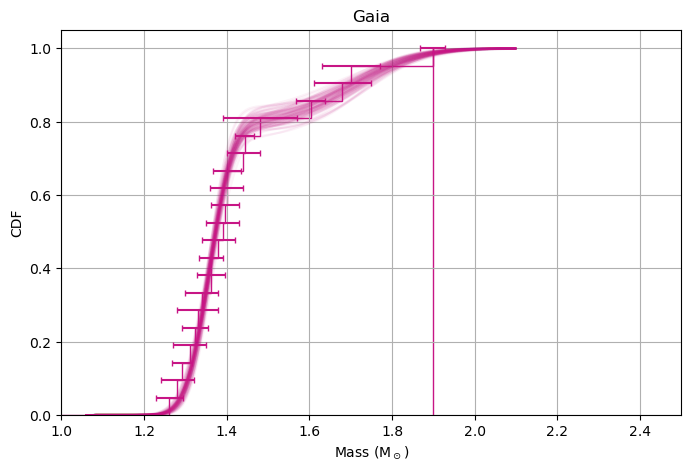

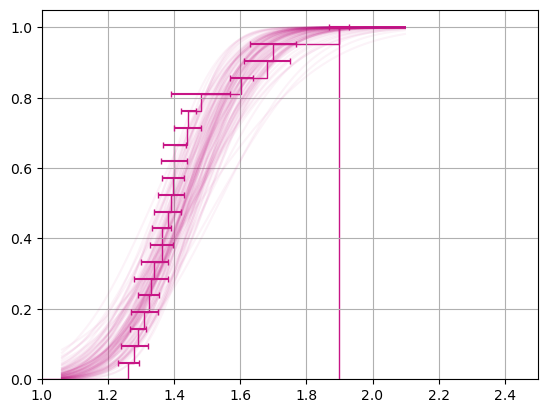

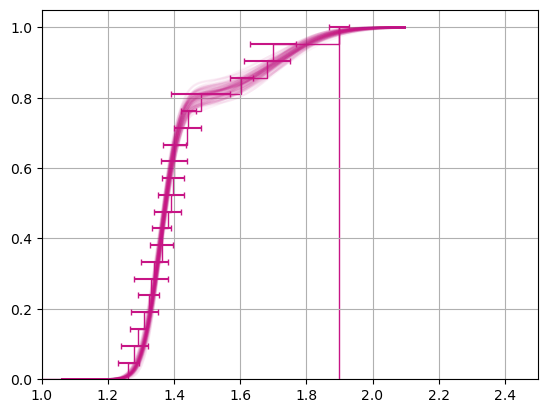

In [310]:
gaiafit = mcmc_double_uniform
gaiafit_single = mcmc_gaussian_uniform
gaiafit_beta = mcmc_double_beta

plt.figure(figsize=(8,5))

gaiafit_samples = gaiafit.get_samples()
gaiafit_single_samples = gaiafit_single.get_samples()
gaiafit_beta_samples = gaiafit_beta.get_samples()

gaia_masses, gaia_uerrors, gaia_lerrors, gaia_bins =plot_cdf(gaia_data,gaia_data_err,gaia_data_err)

x = np.linspace(min(data) - 0.2, max(data) + 0.2, 1000)

for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu1'][i], scale=np.sqrt(gaiafit_samples['sigma1'][i]**2)) +\
        (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu2'][i], scale=np.sqrt(gaiafit_samples['sigma2'][i]**2))
    plt.plot(x, y, alpha=0.05, color='mediumvioletred', label='Gaia')

plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass (M$_\odot$)")
plt.title("Gaia")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

for i in np.random.choice(len(gaiafit_single_samples['mu']), 100, replace=False):
    y = scipy.stats.norm.cdf(x, loc=gaiafit_single_samples['mu'][i], scale=np.sqrt(gaiafit_single_samples['sigma'][i]**2))
    plt.plot(x, y, alpha=0.05, color='mediumvioletred', label='Gaia')

plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)

plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

for i in np.random.choice(len(gaiafit_beta_samples['mu1']), 100, replace=False):    
    y = gaiafit_beta_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=gaiafit_beta_samples['mu1'][i], scale=np.sqrt(gaiafit_beta_samples['sigma1'][i]**2)) +\
        (1 - gaiafit_beta_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=gaiafit_beta_samples['mu2'][i], scale=np.sqrt(gaiafit_beta_samples['sigma2'][i]**2))
    plt.plot(x, y, alpha=0.05, color='mediumvioletred', label='Gaia')
plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')       
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

gaiafit=mcmc_double_beta

# Recycled NS

sample: 100%|██████████| 2000/2000 [00:04<00:00, 409.24it/s, 7 steps of size 4.84e-01. acc. prob=0.90]


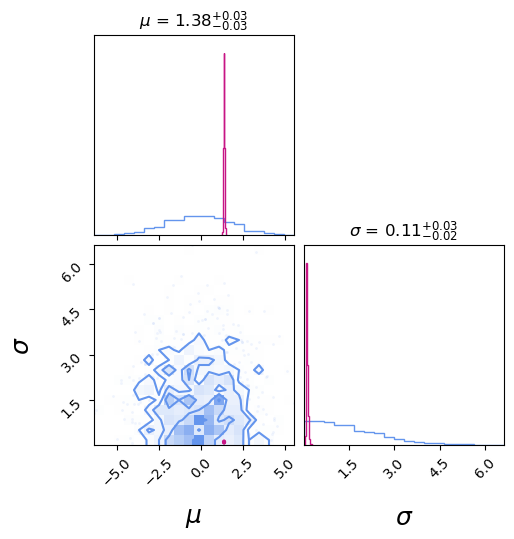

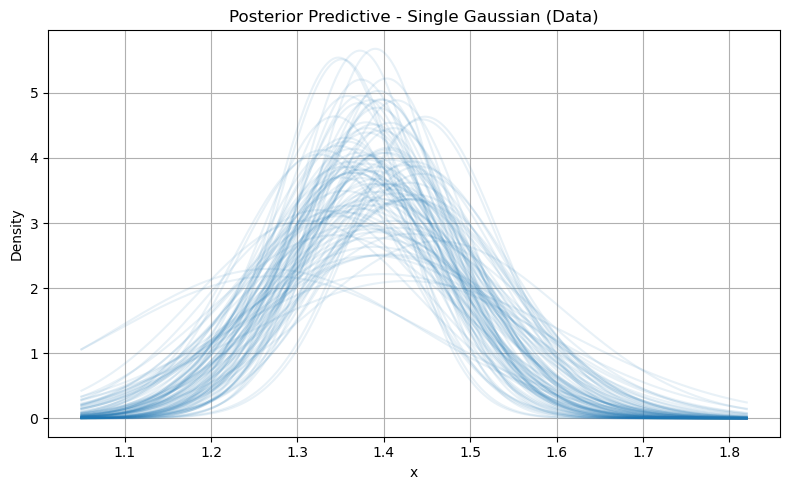

Single Gaussian (Normal Prior):
logl gaussian_normal:  1.9413282





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1601.27it/s, 3 steps of size 8.46e-01. acc. prob=0.91]


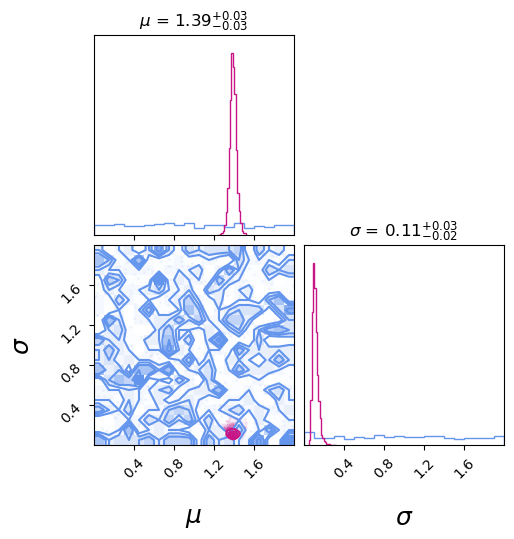

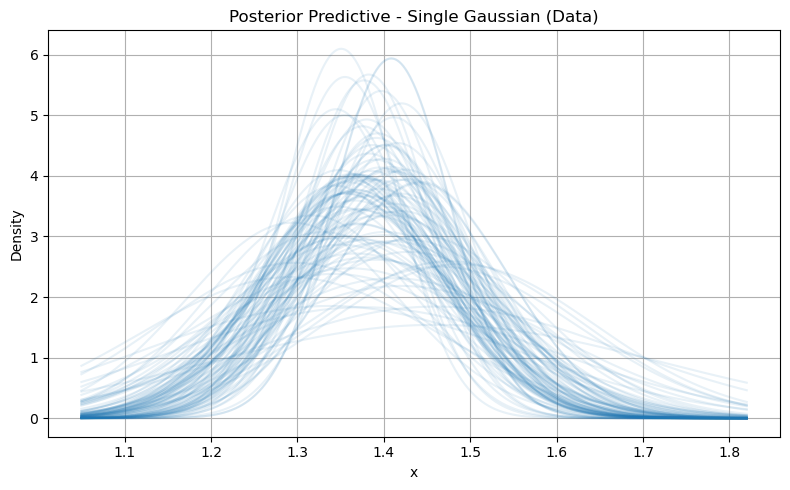

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  2.036761





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1672.78it/s, 7 steps of size 3.78e-01. acc. prob=0.92]


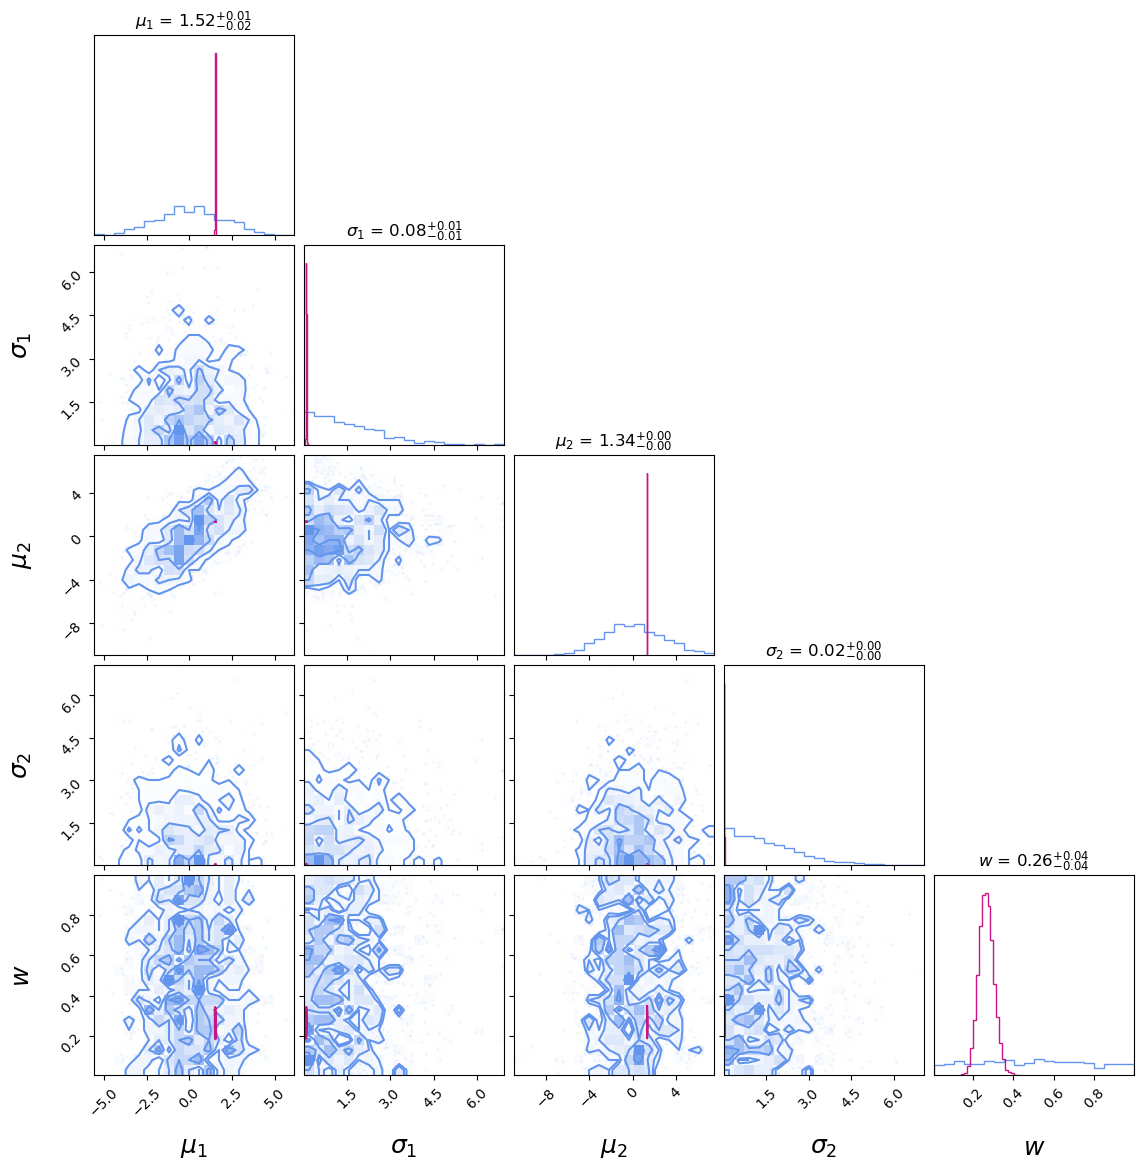

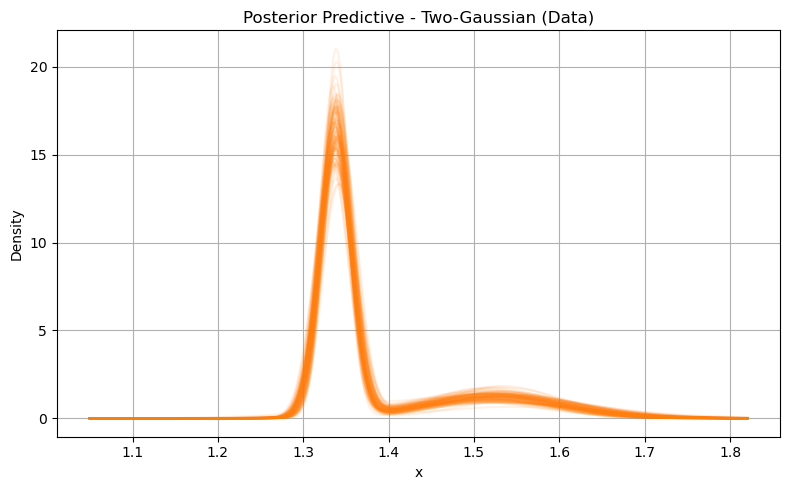

Double Gaussian (Normal Prior):
logl double_normal:  18.279438





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1675.57it/s, 7 steps of size 6.60e-01. acc. prob=0.90]


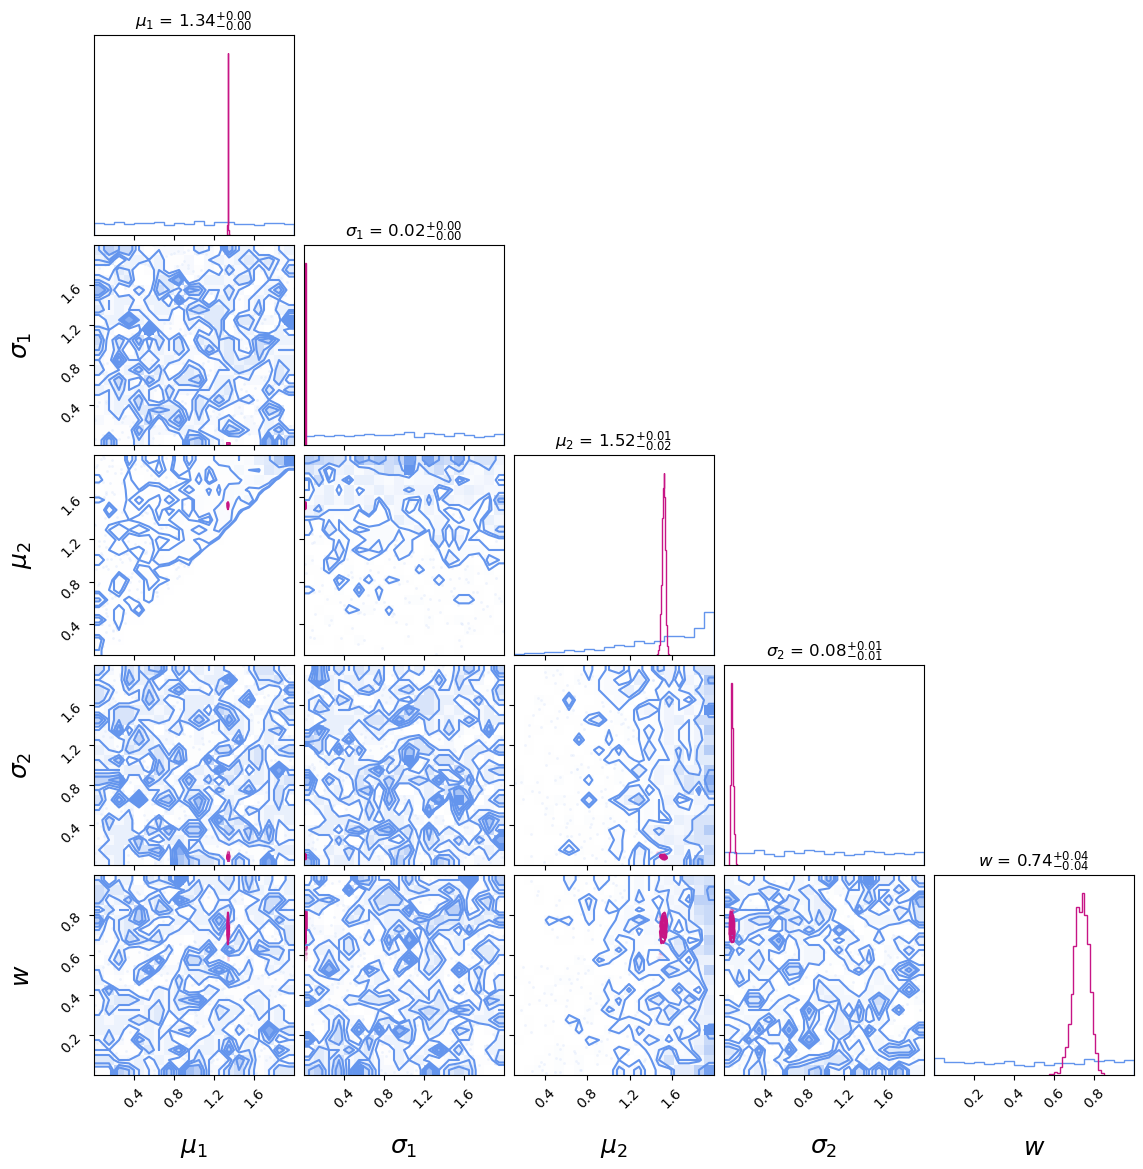

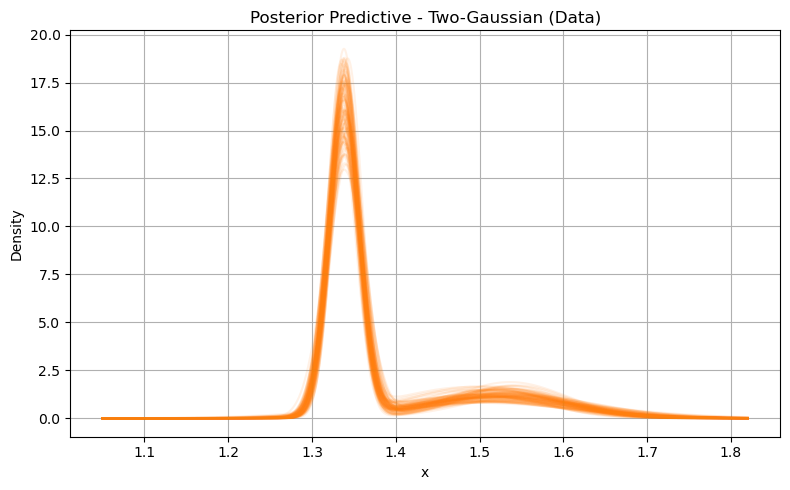

Double Gaussian (Uniform Prior):
logl double_uniform:  18.284243






sample: 100%|██████████| 10000/10000 [00:02<00:00, 4488.75it/s, 3 steps of size 6.34e-01. acc. prob=0.91]


Double Gaussian (Beta Prior):
Log Marginal Likelihood: 235.22



sample: 100%|██████████| 10000/10000 [00:02<00:00, 4481.48it/s, 7 steps of size 6.13e-01. acc. prob=0.92]


Double Gaussian (Beta Prior):
Log Marginal Likelihood: 235.11



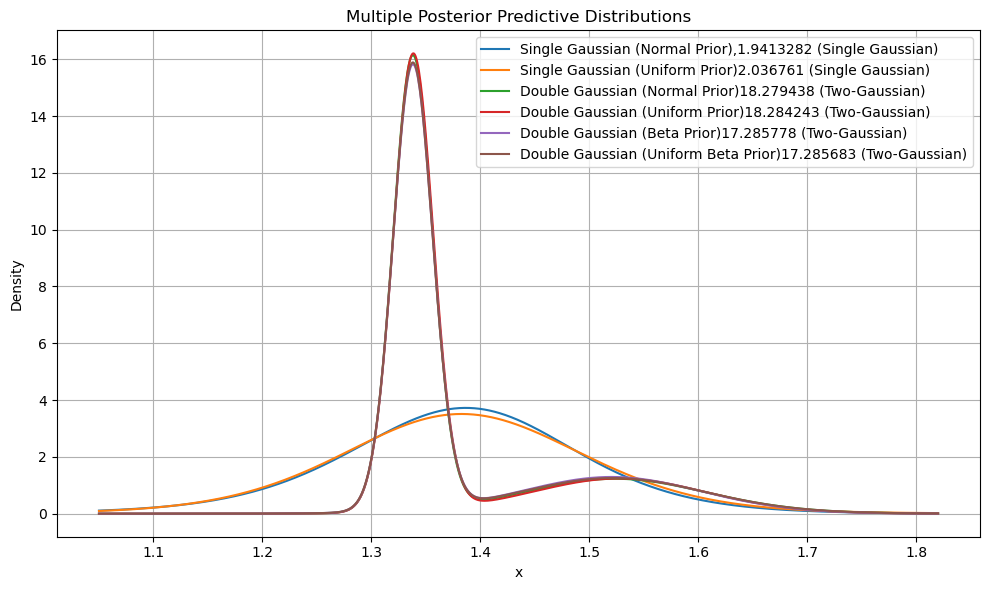

In [345]:
data = DNS['m1'].dropna().to_numpy()
data_err = DNS[['m1_uerr', 'm1_lerr']].max(axis=1).dropna().to_numpy()


rng = random.PRNGKey(0)

# Fit single Gaussian - normal prior
mcmc_gaussian_normal = run_inference(gaussian_normal, data, data_err, rng)
samples_gaussian_normal= az.from_numpyro(mcmc_gaussian_normal)
logZ_gaussian_normal = log_marginal_likelihood(mcmc_gaussian_normal, gaussian_normal, data, data_err)

prior_sampler = MCMC(NUTS(prior_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
corner.corner(
    samples_gaussian_normal,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_normal, "single", "Posterior: Single Gaussian - Normal Prior")
plot_posterior_distributions(mcmc_gaussian_normal, "single", data, label="Data")

print("Single Gaussian (Normal Prior):")
logl_gaussian_normal = log_likelihood(gaussian_normal, mcmc_gaussian_normal.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_normal: ", np.max(logl_gaussian_normal))
print()
print()
print()

# Fit single Gaussian - uniform prior
mcmc_gaussian_uniform = run_inference(gaussian_uniform, data, data_err, rng)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)
logZ_gaussian_uniform = log_marginal_likelihood(mcmc_gaussian_uniform, gaussian_uniform, data, data_err)

prior_sampler = MCMC(NUTS(prior_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_uniform, "single", "Posterior: Single Gaussian - Uniform Prior")
plot_posterior_distributions(mcmc_gaussian_uniform, "single", data, label="Data")


print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()


# Fit two-component Gaussian - normal prior
rng, rng2 = random.split(rng)
mcmc_double_normal = run_inference(double_gaussian_normal, data, data_err, rng2)
samples_double_normal = az.from_numpyro(mcmc_double_normal)
logZ_double_normal = log_marginal_likelihood(mcmc_double_normal, double_gaussian_normal, data, data_err)

prior_sampler = MCMC(NUTS(prior_double_gaussian_normal), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_normal,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()
#corner_plot(mcmc_double_normal, "double", "Posterior: Two-Gaussian Mixture - Normal Prior")
plot_posterior_distributions(mcmc_double_normal, "double", data, label="Data")

print("Double Gaussian (Normal Prior):")
logl_double_normal = log_likelihood(double_gaussian_normal, mcmc_double_normal.get_samples(), data=data, err=data_err)['obs']
print("logl double_normal: ", np.max(logl_double_normal))
print()
print()
print()

# Fit two-component Gaussian - Uniform prior
rng, rng2 = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, data, data_err, rng2)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)
logZ_double_uniform = log_marginal_likelihood(mcmc_double_uniform, double_gaussian_uniform, data, data_err)

DNS_corner_samples = samples_double_uniform

prior_sampler = MCMC(NUTS(prior_double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(random.PRNGKey(0))   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

#corner_plot(mcmc_double_uniform, "double", "Posterior: Two-Gaussian Mixture - Uniform Prior")
plot_posterior_distributions(mcmc_double_uniform, "double", data, label="Data")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=data, err=data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()
print()

# Fit two-component Gaussian - beta weight prior
rng, rng2 = random.split(rng)
mcmc_double_beta = run_inference(double_gaussian_normal_beta, data, data_err, rng2)
samples_double_beta = az.from_numpyro(mcmc_double_beta)
logZ_double_beta = log_marginal_likelihood(mcmc_double_beta, double_gaussian_normal_beta, data, data_err)

print("Double Gaussian (Beta Prior):")
print(f"Log Marginal Likelihood: {logZ_double_normal:.2f}")
print()

# Fit two-component Gaussian - beta uniform prior
rng, rng2 = random.split(rng)
mcmc_double_uniform_beta = run_inference(double_gaussian_uniform_beta, data, data_err, rng2)
samples_double_uniform_beta = az.from_numpyro(mcmc_double_uniform_beta)
logZ_double_uniform_beta = log_marginal_likelihood(mcmc_double_uniform_beta, double_gaussian_uniform_beta, data, data_err)
print("Double Gaussian (Beta Prior):")
print(f"Log Marginal Likelihood: {logZ_double_uniform_beta:.2f}")
print()





plot_multiple_posterior_distributions(
    [mcmc_gaussian_normal, mcmc_gaussian_uniform, mcmc_double_normal, mcmc_double_uniform, mcmc_double_beta, mcmc_double_uniform_beta],
    ["single", "single", "double", "double", "double", "double"],
    data,
    ["Single Gaussian (Normal Prior),"+str(np.max(logl_gaussian_normal)), "Single Gaussian (Uniform Prior)"+str(np.max(logl_gaussian_uniform)), "Double Gaussian (Normal Prior)"+str(np.max(logl_double_normal)),\
      "Double Gaussian (Uniform Prior)"+str(np.max(logl_double_uniform)), "Double Gaussian (Beta Prior)"+str(np.max(logl_beta_normal)), "Double Gaussian (Uniform Beta Prior)"+str(np.max(logl_beta_uniform))]
)

[1.25   1.306  1.322  1.3381 1.34   1.3406 1.341  1.358  1.3655 1.41
 1.4398 1.559  1.62  ] [0.06   0.004  0.011  0.0007 0.08   0.0005 0.007  0.01   0.0021 0.08
 0.0002 0.005  0.03  ]


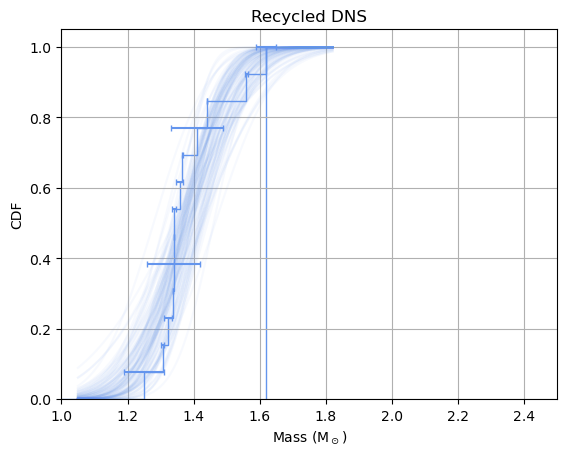

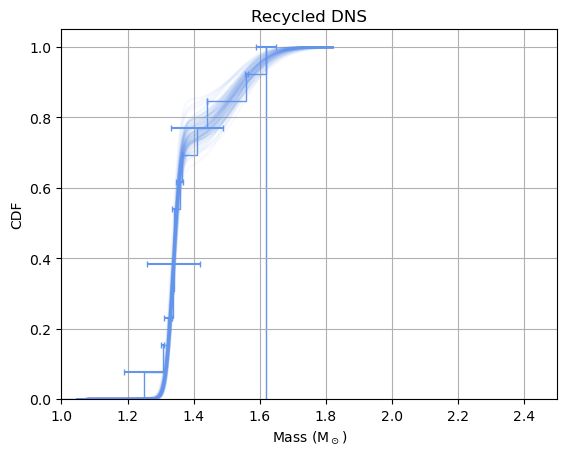

In [313]:
recycledDNSfit = mcmc_double_uniform
recycledDNSfit_samples = recycledDNSfit.get_samples()

recycledDNSfit_single = mcmc_gaussian_uniform
recycledDNSfit_single_samples = recycledDNSfit_single.get_samples()

DNS_masses, DNS_uerrors, DNS_lerrors, DNS_bins =plot_cdf(DNS_data,DNS_data_err,DNS_data_err)


x = np.linspace(min(data) - 0.2, max(data) + 0.2, 1000)

# for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
#     y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=np.sqrt(recycledDNSfit_samples['sigma1'][i]**2)) +\
#         (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=np.sqrt(recycledDNSfit_samples['sigma2'][i]**2))
#     plt.plot(x, y, alpha=0.05, color='cornflowerblue', label='Recycled DNS')

for i in np.random.choice(len(recycledDNSfit_single_samples['mu']), 100, replace=False):
    y = scipy.stats.norm.cdf(x, loc=recycledDNSfit_single_samples['mu'][i], scale=np.sqrt(recycledDNSfit_single_samples['sigma'][i]**2))
    plt.plot(x, y, alpha=0.05, color='cornflowerblue', label='Recycled DNS')

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass (M$_\odot$)")
plt.title("Recycled DNS")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=np.sqrt(recycledDNSfit_samples['sigma1'][i]**2)) +\
        (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=np.sqrt(recycledDNSfit_samples['sigma2'][i]**2))
    plt.plot(x, y, alpha=0.05, color='cornflowerblue', label='Recycled DNS')

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass (M$_\odot$)")
plt.title("Recycled DNS")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()




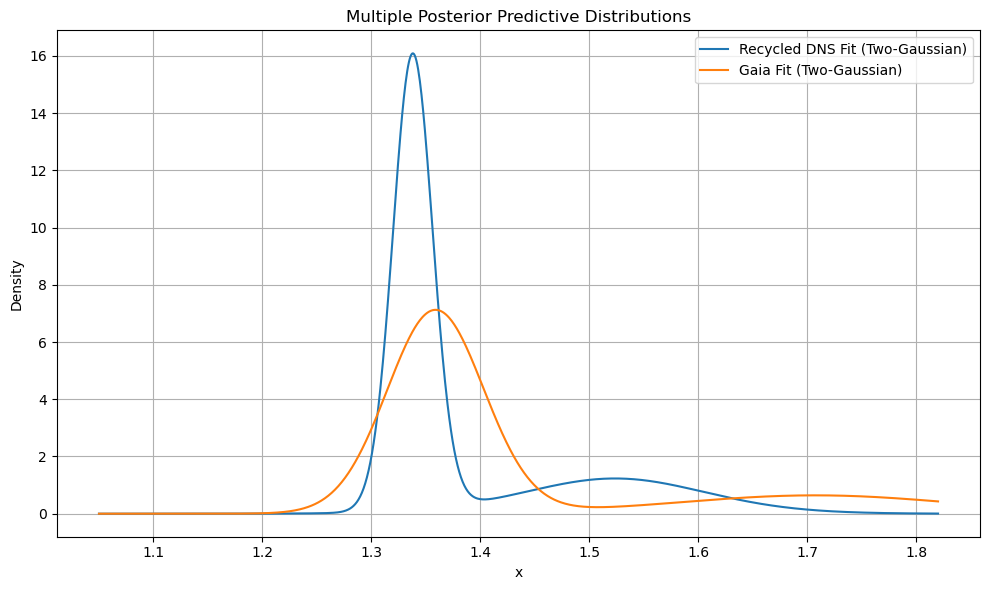

In [307]:
plot_multiple_posterior_distributions([recycledDNSfit, gaiafit], ["double", "double"], data, ["Recycled DNS Fit", "Gaia Fit"])

/var/folders/by/tlp8gdq17q72kgysbfmtlzp40000gn/T/ipykernel_83307/289116068.py:25: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


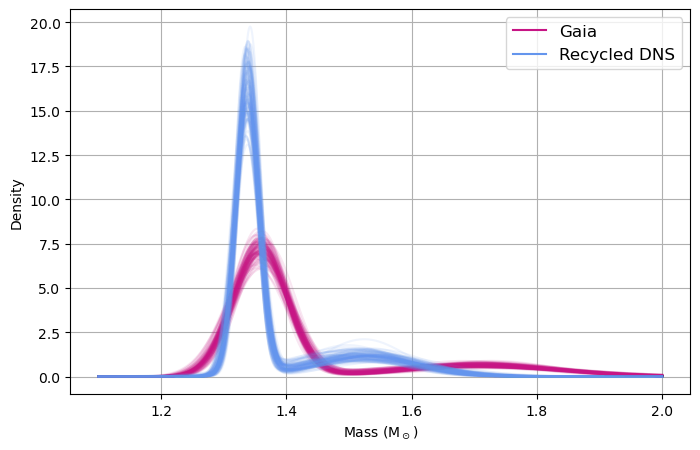

[1.261 1.28  1.291 1.31  1.323 1.33  1.34  1.362 1.362 1.38  1.39  1.396
 1.4   1.401 1.44  1.443 1.48  1.603 1.68  1.7   1.898] [0.032 0.04  0.024 0.04  0.032 0.05  0.04  0.034 0.03  0.04  0.04  0.033
 0.04  0.034 0.04  0.023 0.09  0.035 0.07  0.07  0.03 ]
[1.25   1.306  1.322  1.3381 1.34   1.3406 1.341  1.358  1.3655 1.41
 1.4398 1.559  1.62  ] [0.06   0.004  0.011  0.0007 0.08   0.0005 0.007  0.01   0.0021 0.08
 0.0002 0.005  0.03  ]


/var/folders/by/tlp8gdq17q72kgysbfmtlzp40000gn/T/ipykernel_83307/289116068.py:60: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


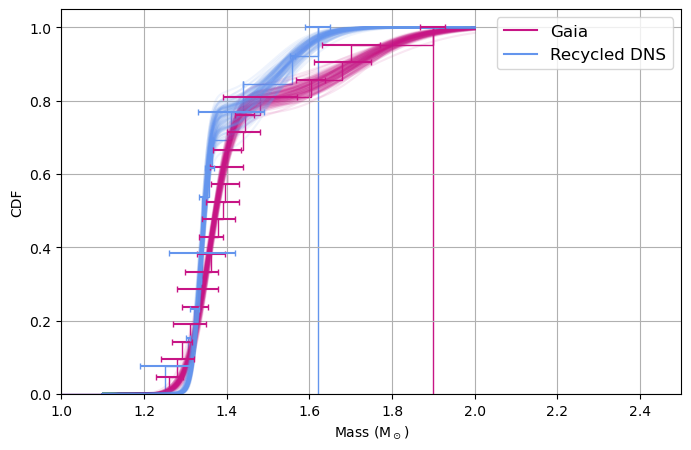

In [329]:
plt.figure(figsize=(8,5))

gaiafit_samples = gaiafit.get_samples()
recycledDNSfit_samples = recycledDNSfit.get_samples()
x = np.linspace(1.1, 2, 1000)

plotN = 0
for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu1'][i], scale=np.sqrt(gaiafit_samples['sigma1'][i]**2)) +\
        (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu2'][i], scale=np.sqrt(gaiafit_samples['sigma2'][i]**2))
    plt.plot(x, y, alpha=0.1, color='mediumvioletred', label='Gaia' if plotN == 0 else None)
    plotN += 1

plotN = 0
for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=np.sqrt(recycledDNSfit_samples['sigma1'][i]**2)) +\
        (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=np.sqrt(recycledDNSfit_samples['sigma2'][i]**2))
    plt.plot(x, y, alpha=0.1, color='cornflowerblue', label= 'Recycled DNS' if plotN == 0 else None)
    plotN += 1

plt.grid()
plt.ylabel("Density")
plt.xlabel("Mass (M$_\odot$)")
legend = plt.legend(frameon=True, loc='best', fontsize=12)
for handle in legend.legendHandles:
    handle.set_alpha(1.0)  # Make the legend handles fully opaque
plt.show()

plt.figure(figsize=(8,5))

gaiafit_samples = gaiafit.get_samples()
recycledDNSfit_samples = recycledDNSfit.get_samples()

gaia_masses, gaia_uerrors, gaia_lerrors, gaia_bins =plot_cdf(gaia_data,gaia_data_err,gaia_data_err)
DNS_masses, DNS_uerrors, DNS_lerrors, DNS_bins =plot_cdf(DNS_data,DNS_data_err,DNS_data_err)


plotN = 0
for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu1'][i], scale=np.sqrt(gaiafit_samples['sigma1'][i]**2)) +\
        (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu2'][i], scale=np.sqrt(gaiafit_samples['sigma2'][i]**2))
    plt.plot(x, y, alpha=0.1, color='mediumvioletred', label='Gaia' if plotN == 0 else None)
    plotN += 1
plotN = 0
for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=np.sqrt(recycledDNSfit_samples['sigma1'][i]**2)) +\
        (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=np.sqrt(recycledDNSfit_samples['sigma2'][i]**2))
    plt.plot(x, y, alpha=0.1, color='cornflowerblue', label= 'Recycled DNS' if plotN == 0 else None)
    plotN += 1
plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.xlim(1.0, 2.5)
plt.grid()
plt.ylabel("CDF")
plt.xlabel("Mass (M$_\odot$)")
legend = plt.legend(frameon=True, loc='best', fontsize=12)
for handle in legend.legendHandles:
    handle.set_alpha(1.0)  # Make the legend handles fully opaque
plt.show()




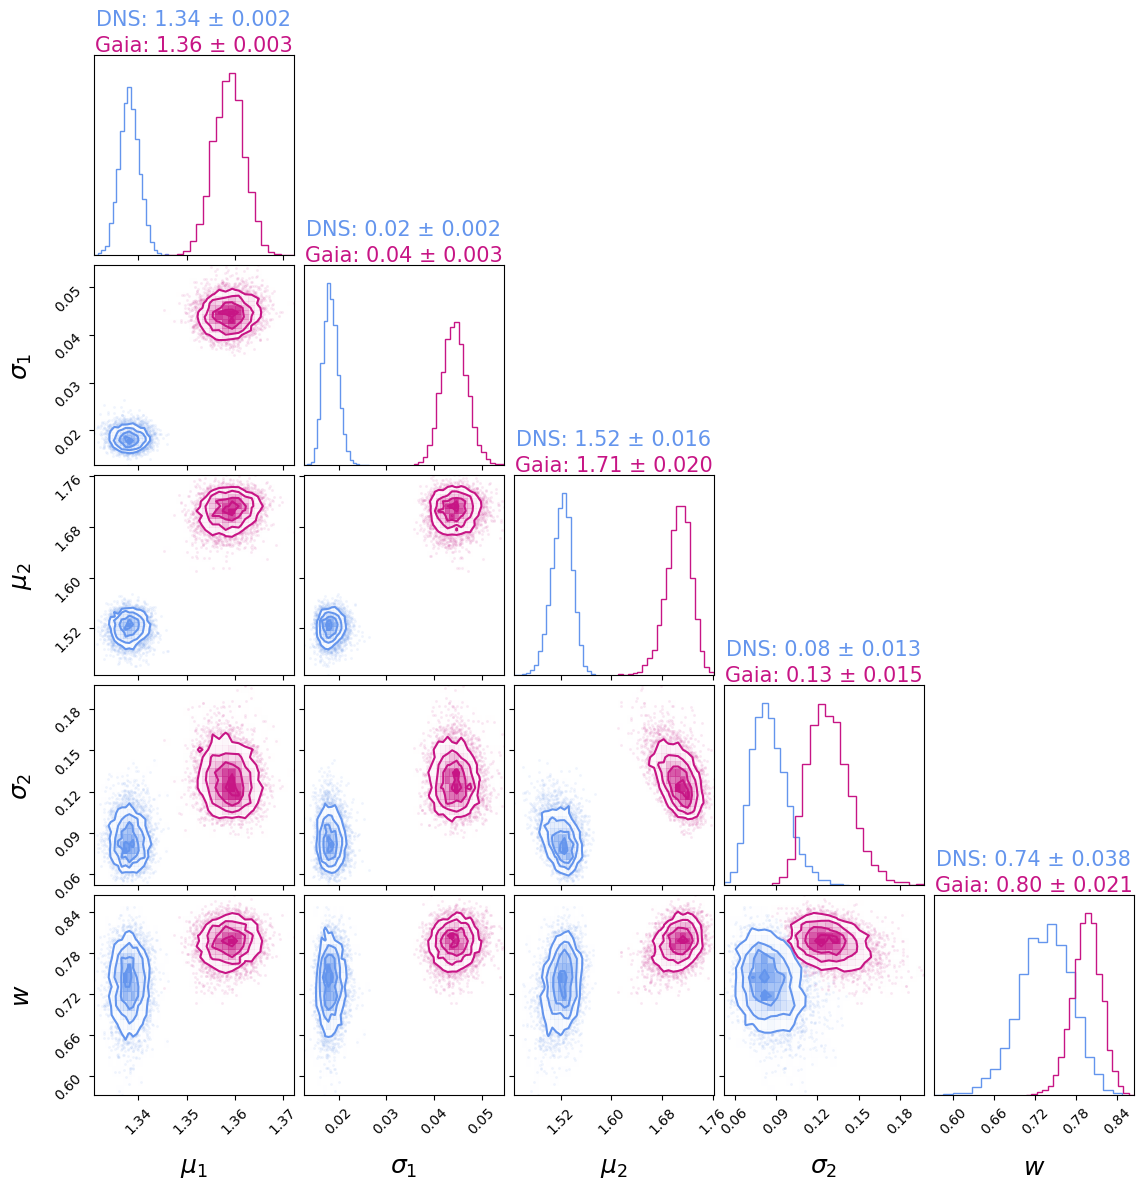

In [360]:
import numpy as np
import matplotlib.pyplot as plt
import corner

# Variables
params = ['mu1', 'sigma1', 'mu2', 'sigma2', 'weight']
labels = [r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"]

# Step 1: Plot both datasets without titles
fig = corner.corner(
    DNS_corner_samples,
    var_names=params,
    labels=labels,
    color='cornflowerblue',
    show_titles=False,
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    gaia_corner_samples,
    var_names=params,
    labels=labels,
    color='mediumvioletred',
    fig=fig,
    show_titles=False,
    label_kwargs=dict(fontsize=18)
)

# Step 2: Add your own titles manually
ndim = len(params)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i, param in enumerate(params):
    ax = axes[i, i]

    # Compute summary stats
    median_dns = np.median(DNS_corner_samples.posterior[param])
    std_dns = np.std(DNS_corner_samples.posterior[param])
    median_gaia = np.median(gaia_corner_samples.posterior[param])
    std_gaia = np.std(gaia_corner_samples.posterior[param])

    # Add DNS title (top line)
    ax.text(0.5, 1.13,
            f"DNS: {median_dns:.2f} ± {std_dns:.3f}",
            fontsize=15, color='cornflowerblue',
            ha='center', va='bottom', transform=ax.transAxes)

    # Add Gaia title (second line just below)
    ax.text(0.5, 1.00,
            f"Gaia: {median_gaia:.2f} ± {std_gaia:.3f}",
            fontsize=15, color='mediumvioletred',
            ha='center', va='bottom', transform=ax.transAxes)
plt.show()

# KS Tests

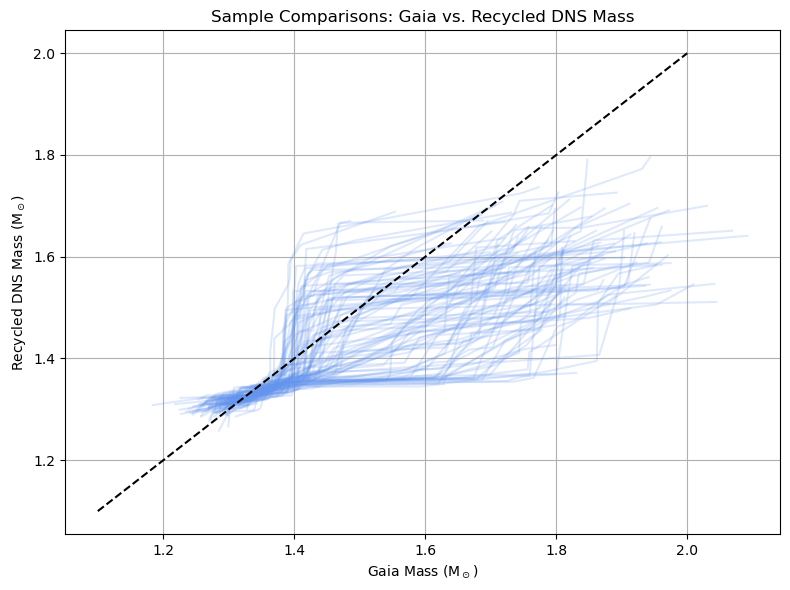

In [342]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

# Function to sample from a 2-component Gaussian mixture
def sample_from_mixture(mu1, sigma1, mu2, sigma2, weight, size=1):
    components = np.random.rand(size) < weight
    samples = np.where(
        components,
        np.random.normal(mu1, sigma1, size),
        np.random.normal(mu2, sigma2, size)
    )
    return samples

# Prepare plot
plt.figure(figsize=(8, 6))

for _ in range(100):  # Draw and plot 100 sample comparisons
    # Draw 21 samples from Gaia fit
    gaia_idxs = np.random.choice(len(gaiafit_samples['mu1']), 21, replace=False)
    gaia_samples = np.array([
        sample_from_mixture(
            gaiafit_samples['mu1'][i],
            (gaiafit_samples['sigma1'][i]),+
            gaiafit_samples['mu2'][i],
            (gaiafit_samples['sigma2'][i]),
            gaiafit_samples['weight'][i]
        )[0] for i in gaia_idxs
    ])

    # Draw 21 samples from recycled DNS fit
    dns_idxs = np.random.choice(len(recycledDNSfit_samples['mu1']), 21, replace=False)
    dns_samples = np.array([
        sample_from_mixture(
            recycledDNSfit_samples['mu1'][i],
            (recycledDNSfit_samples['sigma1'][i]),
            recycledDNSfit_samples['mu2'][i],
            (recycledDNSfit_samples['sigma2'][i]),
            recycledDNSfit_samples['weight'][i]
        )[0] for i in dns_idxs
    ])

    # Plot sorted pairwise comparison
    plt.plot(np.sort(gaia_samples), np.sort(dns_samples), alpha=0.2, color='cornflowerblue')

# Plot y = x reference line
plt.plot([1.1, 2], [1.1, 2], ls='--', color='k', alpha=1)

plt.xlabel("Gaia Mass (M$_\odot$)")
plt.ylabel("Recycled DNS Mass (M$_\odot$)")
plt.grid(True)
plt.title("Sample Comparisons: Gaia vs. Recycled DNS Mass")
plt.tight_layout()
plt.show()


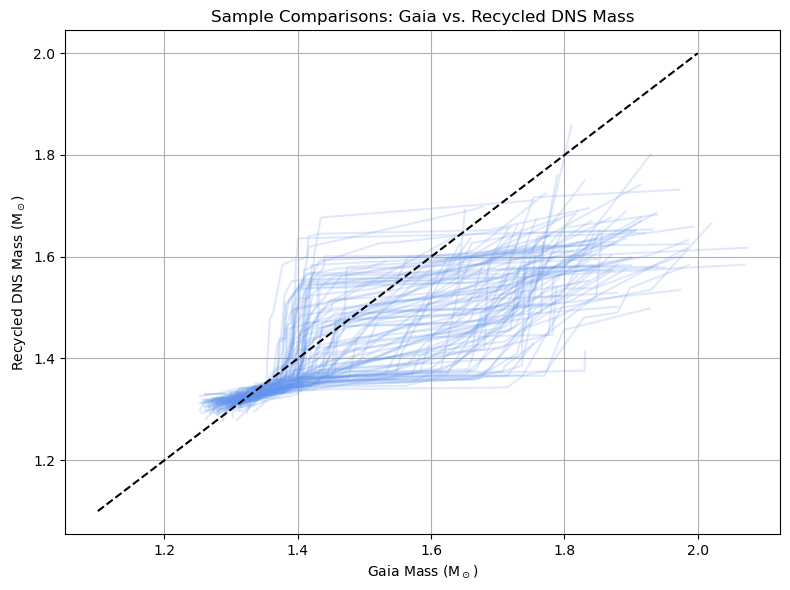

In [340]:
from scipy.stats import truncnorm
import numpy as np
import matplotlib.pyplot as plt

# Function to sample from a truncated normal distribution
def truncated_normal(mean, std, lower, upper, size=1):
    """
    Generate samples from a truncated normal distribution.
    """
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.rvs(a, b, loc=mean, scale=std, size=size)

# Function to sample from a 2-component truncated Gaussian mixture
def sample_from_mixture_truncated(mu1, sigma1, mu2, sigma2, weight, lower, upper, size=1):
    """
    Generate samples from a two-component Gaussian mixture with truncation.
    """
    components = np.random.rand(size) < weight
    samples = np.where(
        components,
        truncated_normal(mu1, sigma1, lower, upper, size),
        truncated_normal(mu2, sigma2, lower, upper, size)
    )
    return samples

# Prepare plot
plt.figure(figsize=(8, 6))

lower, upper = 1.25, 2.5  # Truncation bounds

for _ in range(100):  # Draw and plot 1000 sample comparisons
    # Draw 21 samples from Gaia fit
    gaia_idxs = np.random.choice(len(gaiafit_samples['mu1']), 21, replace=False)
    gaia_samples = np.array([
        sample_from_mixture_truncated(
            gaiafit_samples['mu1'][i],
            (gaiafit_samples['sigma1'][i]),
            gaiafit_samples['mu2'][i],
            (gaiafit_samples['sigma2'][i]),
            gaiafit_samples['weight'][i],
            lower, upper
        )[0] for i in gaia_idxs
    ])

    # Draw 21 samples from recycled DNS fit
    dns_idxs = np.random.choice(len(recycledDNSfit_samples['mu1']), 21, replace=False)
    dns_samples = np.array([
        sample_from_mixture_truncated(
            recycledDNSfit_samples['mu1'][i],
            (recycledDNSfit_samples['sigma1'][i]),
            recycledDNSfit_samples['mu2'][i],
           (recycledDNSfit_samples['sigma2'][i]),
            recycledDNSfit_samples['weight'][i],
            lower, upper
        )[0] for i in dns_idxs
    ])

    # Plot sorted pairwise comparison
    plt.plot(np.sort(gaia_samples), np.sort(dns_samples), alpha=0.2, color='cornflowerblue')

# Plot y = x reference line
plt.plot([1.1, 2], [1.1, 2], ls='--', color='k', alpha=1)

plt.xlabel("Gaia Mass (M$_\\odot$)")
plt.ylabel("Recycled DNS Mass (M$_\\odot$)")
plt.grid(True)
plt.title("Sample Comparisons: Gaia vs. Recycled DNS Mass")
plt.tight_layout()
plt.show()